# Sub-basin overlap demo

This notebook shows how to identify sub-basins that fall partially or entirely within a command area mask. It loads the rasters, aligns their grids, tabulates which basins overlap the mask, and visualizes the selected basins.

## Requirements
- `rioxarray` (and `rasterio` under the hood)
- `geopandas`
- `shapely`
- `matplotlib`
- `pandas`

Install any missing packages in your environment before running the notebook.

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
import rasterio
from rasterio.features import shapes, rasterize
from shapely.geometry import shape
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [21]:
# Update these paths if your directory layout is different
DATA_DIR = Path("population data")
SUBBASIN_PATH = DATA_DIR / "SubBasin_Area.tif"
COMMAND_MASK_PATH = DATA_DIR / "combined_command_area_mask_EPSG4326_90m.tif"

SUBBASIN_PATH, COMMAND_MASK_PATH

(PosixPath('population data/SubBasin_Area.tif'),
 PosixPath('population data/combined_command_area_mask_EPSG4326_90m.tif'))

## Load and align rasters
`rioxarray` automatically tracks georeferencing so we can reproject the mask to match the sub-basin raster. The mask values are assumed to be 1 for in-mask pixels and 0 (or nodata) elsewhere.

In [22]:
subbasins = rxr.open_rasterio(SUBBASIN_PATH, masked=True).squeeze("band")
command_mask = rxr.open_rasterio(COMMAND_MASK_PATH, masked=True).squeeze("band")
print(f"Sub-basin CRS: {subbasins.rio.crs}")
print(f"Sub-basin resolution: {subbasins.rio.resolution()}")

print(f"Command mask CRS: {command_mask.rio.crs}")
print(f"Command mask resolution: {command_mask.rio.resolution()}")

# Align command mask grid to sub-basin raster to make pixel-wise comparisons valid
mask_aligned = command_mask.rio.reproject_match(subbasins)

subbasins, mask_aligned
BASIN_NODATA_VALUE = 65535


Sub-basin CRS: EPSG:4326
Sub-basin resolution: (0.0024150010043090388, -0.002415001004309039)
Command mask CRS: EPSG:4326
Command mask resolution: (0.000833332760989011, -0.0008333327969102032)


## Identify partial vs entire overlap
The code below compares every sub-basin ID with the aligned mask. A basin is
- **`entirely_in_mask`** if every valid pixel for that basin intersects the mask.
- **`partially_in_mask`** if at least one pixel intersects the mask but not all of them.

The resulting dataframe also includes the fraction of basin pixels that fall within the mask, which can be used later for filtering by coverage threshold.

In [23]:
sub_data = subbasins.data
mask_data = mask_aligned.data

# Build a mask for valid sub-basin pixels (exclude nodata/zero background)
valid = (~np.isnan(sub_data)) & (sub_data > 0)
valid &= sub_data != BASIN_NODATA_VALUE

sub_ids = sub_data[valid].astype(int)
mask_hits = np.where(np.isnan(mask_data[valid]), 0, mask_data[valid] > 0)

coverage = (
    pd.DataFrame({"basin_id": sub_ids, "in_mask": mask_hits})
    .groupby("basin_id")
    .agg(total_pixels=("in_mask", "count"), pixels_in_mask=("in_mask", "sum"))
)
coverage["coverage_fraction"] = coverage["pixels_in_mask"] / coverage["total_pixels"]
coverage["status"] = np.select(
    [coverage["pixels_in_mask"] == 0,
     coverage["pixels_in_mask"] == coverage["total_pixels"]],
    ["outside", "entire"],
    default="partial",
)

coverage.sort_values("coverage_fraction", ascending=False).head()


,total_pixels,pixels_in_mask,coverage_fraction,status
basin_id,,,,
537,396,396,1.0,entire
366,336,336,1.0,entire
1351,402,402,1.0,entire
378,8,8,1.0,entire
1353,201,201,1.0,entire


## Select basin IDs
We can now grab the IDs for basins that are partial or entire, depending on the analysis need. Here we keep both categories (anything except `outside`).

In [24]:
selected = coverage[coverage["status"].isin(["partial", "entire"]) ]
selected_ids = selected.index.to_list()
print(f"Selected basins: {len(selected_ids)} total")
selected.head()

Selected basins: 360 total


,total_pixels,pixels_in_mask,coverage_fraction,status
basin_id,,,,
173,1150,155,0.134783,partial
174,4352,166,0.038143,partial
188,1312,688,0.524390,partial
189,1780,181,0.101685,partial
192,2477,120,0.048446,partial


## Convert selected basins to polygons
`rasterio.features.shapes` vectorizes contiguous pixel regions. We keep only shapes whose value corresponds to the selected basin IDs and store the overlap status for plotting.

In [25]:
with rasterio.open(SUBBASIN_PATH) as src:
    raster_arr = src.read(1)
    transform = src.transform

geoms = []
status_lookup = selected["status"].to_dict()

for geom, basin_val in shapes(raster_arr, mask=np.isin(raster_arr, selected_ids), transform=transform):
    if basin_val in status_lookup:
        geoms.append({
            "geometry": shape(geom),
            "basin_id": int(basin_val),
            "status": status_lookup[basin_val]
        })

selected_gdf = gpd.GeoDataFrame(geoms, crs=subbasins.rio.crs)
selected_gdf.head()

,geometry,basin_id,status
0,"POLYGON ((79.61073 30.65172, 79.61073 30.64931...",173,partial
1,"POLYGON ((79.46825 30.6324, 79.46825 30.62999,...",188,partial
2,"POLYGON ((79.38614 30.65414, 79.38614 30.65172...",189,partial
3,"POLYGON ((79.70733 30.67829, 79.70733 30.65172...",174,partial
4,"POLYGON ((79.35474 30.64689, 79.35474 30.62757...",192,partial


## Visualize overlap
The plot below overlays the command area mask raster with the vectorized basins. Basins entirely within the mask are drawn in one color and partially overlapping basins in another.

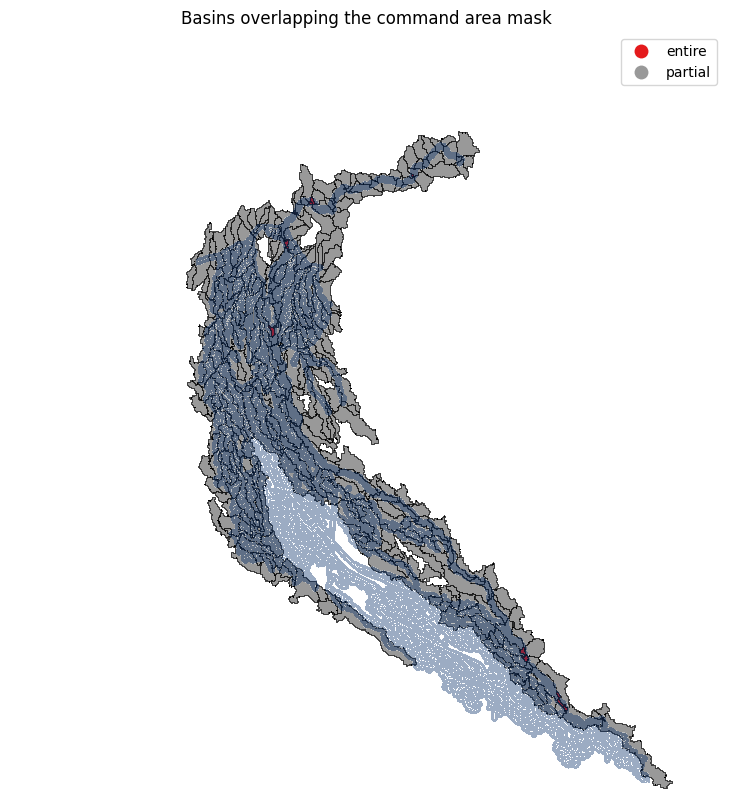

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))

selected_gdf.plot(
    ax=ax,
    column="status",
    cmap="Set1",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)
mask_aligned.plot(ax=ax, cmap="Blues", alpha=0.4, add_colorbar=False)

ax.set_title("Basins overlapping the command area mask")
ax.set_axis_off()
plt.show()

## Select basins using plume path and canal network
To compare alternative selection methods, we load the plume path shapefile and canal raster, bring them into the sub-basin projection, and flag any basins intersected by either dataset.

In [27]:
PLUME_PATH = DATA_DIR / "plume path on river network_EPSG4326_30m.shp"
CANAL_RASTER_PATH = DATA_DIR / "canal_raster_30m.tif"

plume_gdf = gpd.read_file(PLUME_PATH)
print(f"Plume path CRS before reprojection: {plume_gdf.crs}")
plume_gdf = plume_gdf.to_crs(subbasins.rio.crs)
print(f"Plume path CRS after reprojection: {plume_gdf.crs}")

canal_raster = rxr.open_rasterio(CANAL_RASTER_PATH, masked=True).squeeze("band")
print(f"Canal raster CRS before reprojection: {canal_raster.rio.crs}")
canal_aligned = canal_raster.rio.reproject_match(subbasins)
print(f"Canal raster CRS after reprojection: {canal_aligned.rio.crs}")

Plume path CRS before reprojection: EPSG:4326
Plume path CRS after reprojection: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Canal raster CRS before reprojection: PROJCS["WGS_1984_Lambert_Conformal_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.4729444],PARAMETER["standard_parallel_2",35.17280555],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9

In [28]:
sub_array = subbasins.data
valid_pixels = (~np.isnan(sub_array)) & (sub_array > 0) & (sub_array != BASIN_NODATA_VALUE)

plume_shapes = [(geom, 1) for geom in plume_gdf.geometry if not geom.is_empty]
plume_mask = rasterize(
    plume_shapes,
    out_shape=subbasins.shape,
    transform=subbasins.rio.transform(),
    fill=0,
    dtype="uint8"
)

plume_basin_ids = np.unique(sub_array[(plume_mask > 0) & valid_pixels])
plume_basin_ids = plume_basin_ids[~np.isnan(plume_basin_ids)].astype(int)
print(f"Basins intersecting plume path: {len(plume_basin_ids)}")


Basins intersecting plume path: 85


In [29]:
canal_mask = (~np.isnan(canal_aligned.data)) & (canal_aligned.data > 0)
canal_basin_ids = np.unique(sub_array[canal_mask & valid_pixels])
canal_basin_ids = canal_basin_ids[~np.isnan(canal_basin_ids)].astype(int)
print(f"Basins intersecting canal raster: {len(canal_basin_ids)}")


Basins intersecting canal raster: 221


In [30]:
plume_set = set(plume_basin_ids.tolist())
canal_set = set(canal_basin_ids.tolist())

comparison = pd.DataFrame({
    "basin_id": sorted(plume_set | canal_set)
})
comparison["from_plume"] = comparison["basin_id"].isin(plume_set)
comparison["from_canal"] = comparison["basin_id"].isin(canal_set)
comparison["selection_match"] = np.where(
    comparison["from_plume"] == comparison["from_canal"],
    "same",
    "different"
)

only_plume = sorted(plume_set - canal_set)
only_canal = sorted(canal_set - plume_set)

print(f"Basins common to both: {len(plume_set & canal_set)}")
print(f"Only plume: {len(only_plume)} | Only canal: {len(only_canal)}")
comparison.head()

Basins common to both: 24
Only plume: 61 | Only canal: 197


,basin_id,from_plume,from_canal,selection_match
0,188,True,False,different
1,194,True,False,different
2,202,True,False,different
3,208,True,False,different
4,209,True,False,different


### Visualize basins selected from plume/canal inputs
This map highlights the basins triggered by the plume path and canal datasets after reprojection to the sub-basin grid.

In [31]:
def basins_lookup_to_gdf(id_lookup, label_field="selection"):
    with rasterio.open(SUBBASIN_PATH) as src:
        raster_arr = src.read(1)
        transform = src.transform

    mask_arr = np.isin(raster_arr, list(id_lookup.keys()))
    geoms = []
    for geom, basin_val in shapes(raster_arr, mask=mask_arr, transform=transform):
        basin_val = int(basin_val)
        label = id_lookup.get(basin_val)
        if label is None:
            continue
        geoms.append({
            "geometry": shape(geom),
            "basin_id": basin_val,
            label_field: label,
        })
    return gpd.GeoDataFrame(geoms, crs=subbasins.rio.crs)

plume_canal_lookup = {}
for basin_id in sorted(plume_set | canal_set):
    if basin_id in plume_set and basin_id in canal_set:
        status = "plume+canal"
    elif basin_id in plume_set:
        status = "plume_only"
    else:
        status = "canal_only"
    plume_canal_lookup[basin_id] = status

plume_canal_gdf = basins_lookup_to_gdf(plume_canal_lookup)
plume_canal_gdf.head()

,geometry,basin_id,selection
0,"POLYGON ((79.46825 30.6324, 79.46825 30.62999,...",188,plume_only
1,"POLYGON ((79.67594 30.60584, 79.67594 30.60101...",202,plume_only
2,"POLYGON ((79.69284 30.4875, 79.69284 30.46335,...",208,plume_only
3,"POLYGON ((79.49481 30.52856, 79.49481 30.52614...",194,plume_only
4,"POLYGON ((79.42236 30.46577, 79.42236 30.46335...",209,plume_only


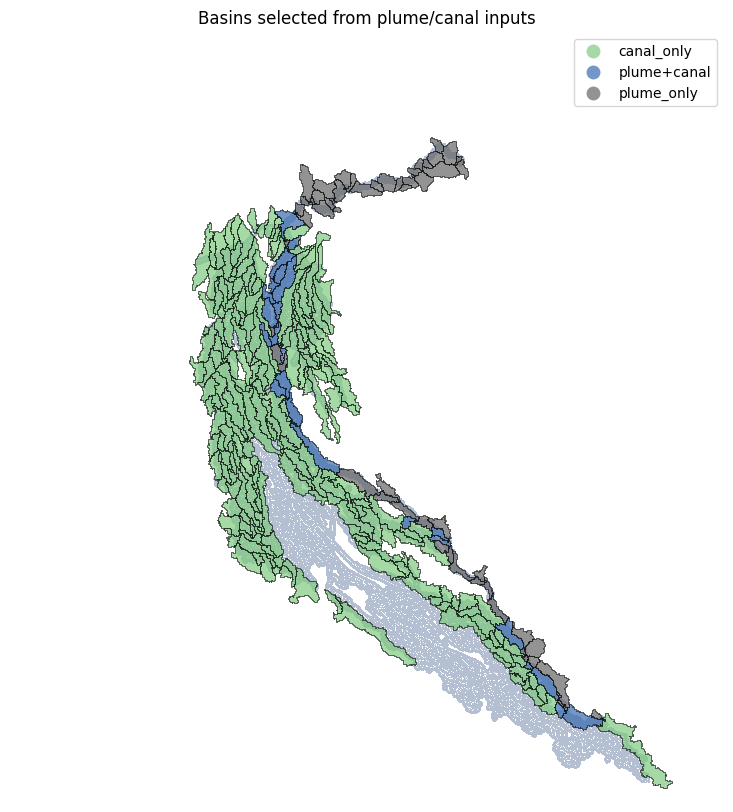

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))
mask_aligned.plot(ax=ax, cmap="Blues", alpha=0.3, add_colorbar=False)

if plume_canal_gdf.empty:
    ax.set_title("No basins selected from plume/canal inputs")
else:
    plume_canal_gdf.plot(
        ax=ax,
        column="selection",
        cmap="Accent",
        edgecolor="black",
        linewidth=0.6,
        legend=True,
        alpha=0.7,
    )
    ax.set_title("Basins selected from plume/canal inputs")

ax.set_axis_off()
plt.show()


### Compare selection methods
Overlap the plume/canal-based basins with the mask-selected basins from earlier to see where they agree or diverge.

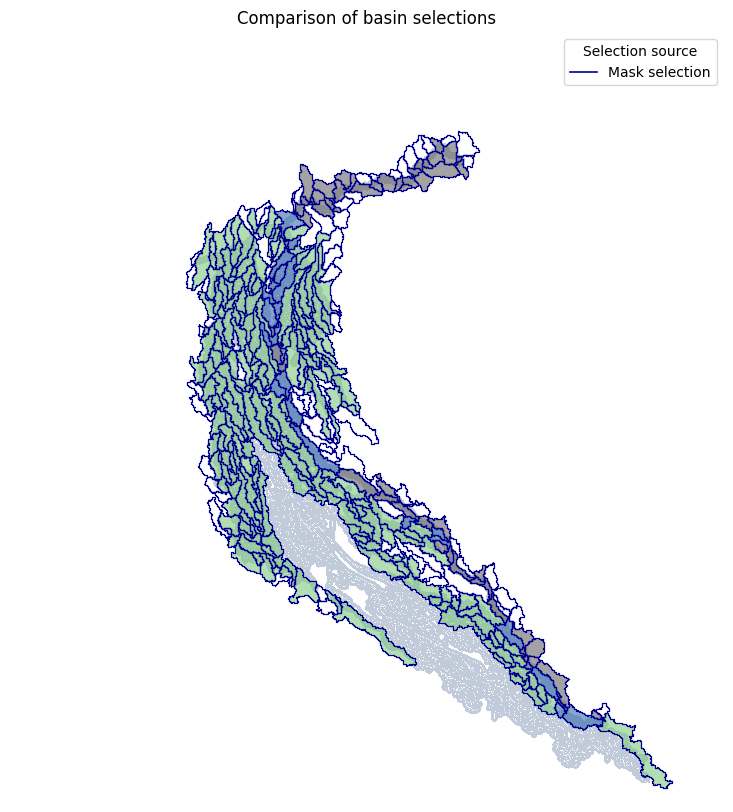

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))
mask_aligned.plot(ax=ax, cmap="Blues", alpha=0.25, add_colorbar=False)

if not plume_canal_gdf.empty:
    plume_canal_gdf.plot(
        ax=ax,
        column="selection",
        cmap="Accent",
        alpha=0.6,
        legend=True,
        edgecolor="black",
        linewidth=0.5,
    )

selected_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#00008B",
    linewidth=0.9,
)

handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color="#00008B", linewidth=1.2, label="Mask selection"))
ax.legend(handles=handles, title="Selection source")
ax.set_title("Comparison of basin selections")
ax.set_axis_off()
plt.show()


### Choose downstream selection method
Use this cell to pick which basin selection (mask overlap vs plume/canal hits) feeds subsequent analysis. Change `SELECTION_METHOD` to swap later without recomputing upstream steps.

In [34]:
selection_options = {
    "mask": {
        "description": "Command mask overlap",
        "ids": set(selected.index.astype(int)),
        "gdf": selected_gdf,
    },
    "plume_canal": {
        "description": "Plume path or canal network hits",
        "ids": set(plume_set | canal_set),
        "gdf": plume_canal_gdf,
    },
}

SELECTION_METHOD = "mask"  # change to "plume_canal" as needed
active_selection = selection_options[SELECTION_METHOD]
active_selection_ids = active_selection["ids"]
active_selection_gdf = active_selection["gdf"]
print(f"Using {SELECTION_METHOD} selection: {active_selection['description']}")
print(f"Total basins selected: {len(active_selection_ids)}")


Using mask selection: Command mask overlap
Total basins selected: 360


### Match plume observation points to selected basins
Sample every plume observation (river and canal) to record the sub-basin ID they fall inside and keep those that intersect the active selection. Canal points remain available for later validation.

In [35]:
PLUME_POINTS_PATH = DATA_DIR / "plume observation points.csv"
plume_points = (
    pd.read_csv(PLUME_POINTS_PATH)
    # .query("location_type != 'canal'")
    .sort_values("event_date")
    .reset_index(drop=True)
)
print(f"Loaded {len(plume_points)} plume observation points")

plume_points_gdf = gpd.GeoDataFrame(
    plume_points,
    geometry=gpd.points_from_xy(plume_points.longitude, plume_points.latitude),
    crs="EPSG:4326",
)
plume_points_proj = plume_points_gdf.to_crs(subbasins.rio.crs)

with rasterio.open(SUBBASIN_PATH) as src:
    coords = [(geom.x, geom.y) for geom in plume_points_proj.geometry]
    sampled = list(src.sample(coords))
basin_values = np.array([vals[0] if vals else np.nan for vals in sampled])

valid_ids = (~np.isnan(basin_values)) & (basin_values != BASIN_NODATA_VALUE)
subbasin_ids = pd.Series(np.where(valid_ids, basin_values, np.nan)).astype("Int64")
plume_points_proj["subbasin_id"] = subbasin_ids

points_in_selection = plume_points_proj[
    plume_points_proj["subbasin_id"].isin(active_selection_ids)
].copy()

print(f"Points intersecting active selection ({SELECTION_METHOD}): {len(points_in_selection)}")
points_in_selection.head()


Loaded 12 plume observation points
Points intersecting active selection (mask): 10


,fid,event_date,event turbidity (NDTI),pre_event_date,post_event_date,location_type,notes,latitude,longitude,date of water turning clear for the first time after the event,note,geometry,subbasin_id
0,1,08/02/2021,NaN,07/02/2021,11/02/2021,dam,NaN,30.25279,78.86828,14/10/2021,stayed high turbility during the monsoon seas...,POINT (78.86828 30.25279),259
1,2,10/02/2021,NaN,08/02/2021,15/02/2021,dam,NaN,29.98287,78.20111,26/03/2021,turbidity went down due to the upstream dam co...,POINT (78.20111 29.98287),320
2,10,11/02/2021,NaN,10/02/2021,14/02/2021,canal,post scene images cloudy could introduce errors,29.55862,77.88201,15/10/2021,stayed high turbility during the monsoon seas...,POINT (77.88201 29.55862),453
3,3,14/02/2021,NaN,08/02/2021,15/02/2021,dam,NaN,28.22989,78.37665,20/03/2021,NaN,POINT (78.37665 28.22989),796
5,4,16/02/2021,NaN,15/02/2021,19/02/2021,braided river,NaN,27.80555,79.09013,01/03/2021,NaN,POINT (79.09013 27.80555),980


### Derive basin ID ranges between plume observations
Focus on river plume points (excluding canal observations) to build ID ranges between successive events. These ranges capture the basins newly affected between two observation dates.

In [36]:
river_points = plume_points_proj[plume_points_proj["location_type"].str.lower() != "canal"].copy()
river_points = river_points.dropna(subset=["subbasin_id"])
river_points = river_points.sort_values("event_date").reset_index(drop=True)
river_points["subbasin_id"] = river_points["subbasin_id"].astype(int)

river_ranges = []
prev_id = None
prev_date = None
for _, row in river_points.iterrows():
    current_id = row["subbasin_id"]
    current_date = row["event_date"]
    if prev_id is None:
        range_desc = f"<= {current_id}"
        lower_bound = None
    else:
        range_desc = f">= {prev_id} and < {current_id}"
        lower_bound = prev_id
    river_ranges.append({
        "event_date": current_date,
        "subbasin_id": current_id,
        "previous_event_date": prev_date,
        "lower_bound_id": lower_bound,
        "upper_bound_id": current_id,
        "range_condition": range_desc,
    })
    prev_id = current_id
    prev_date = current_date

river_ranges_df = pd.DataFrame(river_ranges)
print("River plume observations")
river_points[["event_date", "location_type", "subbasin_id"]]
print("Derived basin ID ranges")
river_ranges_df


River plume observations
Derived basin ID ranges


,event_date,subbasin_id,previous_event_date,lower_bound_id,upper_bound_id,range_condition
0,08/02/2021,259,None,NaN,259,<= 259
1,10/02/2021,320,08/02/2021,259.0,320,>= 259 and < 320
2,14/02/2021,796,10/02/2021,320.0,796,>= 320 and < 796
3,16/02/2021,980,14/02/2021,796.0,980,>= 796 and < 980
4,17/02/2021,1049,16/02/2021,980.0,1049,>= 980 and < 1049
5,18/02/2021,1114,17/02/2021,1049.0,1114,>= 1049 and < 1114
6,19/02/2021,1186,18/02/2021,1114.0,1186,>= 1114 and < 1186
7,22/02/2021,1303,19/02/2021,1186.0,1303,>= 1186 and < 1303
8,25/02/2021,1342,22/02/2021,1303.0,1342,>= 1303 and < 1342


### Map basins affected between plume observations
Using the basin ID ranges, highlight the sub-basins impacted between each pair of plume events. Colors increment sequentially so newer ranges appear darker.

In [37]:
river_points

,fid,event_date,event turbidity (NDTI),pre_event_date,post_event_date,location_type,notes,latitude,longitude,date of water turning clear for the first time after the event,note,geometry,subbasin_id
0,1,08/02/2021,NaN,07/02/2021,11/02/2021,dam,NaN,30.25279,78.86828,14/10/2021,stayed high turbility during the monsoon seas...,POINT (78.86828 30.25279),259
1,2,10/02/2021,NaN,08/02/2021,15/02/2021,dam,NaN,29.98287,78.20111,26/03/2021,turbidity went down due to the upstream dam co...,POINT (78.20111 29.98287),320
2,3,14/02/2021,NaN,08/02/2021,15/02/2021,dam,NaN,28.22989,78.37665,20/03/2021,NaN,POINT (78.37665 28.22989),796
3,4,16/02/2021,NaN,15/02/2021,19/02/2021,braided river,NaN,27.80555,79.09013,01/03/2021,NaN,POINT (79.09013 27.80555),980
4,5,17/02/2021,NaN,11/02/2021,18/02/2021,braided river,NaN,27.61719,79.39302,28/02/2021,NaN,POINT (79.39302 27.61719),1049
5,6,18/02/2021,NaN,16/02/2021,21/02/2021,braided river,no super dove full coverage,27.37898,79.65413,28/02/2021,NaN,POINT (79.65413 27.37898),1114
6,7,19/02/2021,NaN,18/02/2021,21/02/2021,braided river,NaN,27.16688,79.87271,28/02/2021,NaN,POINT (79.87271 27.16688),1186
7,8,22/02/2021,NaN,20/02/2021,23/02/2021,dam,use 23/02/2021 as post of 22,26.57028,80.28992,28/02/2021,NaN,POINT (80.28992 26.57028),1303
8,9,25/02/2021,NaN,23/02/2021,01/03/2021,braided river,NaN,26.40202,80.46341,01/03/2021,NaN,POINT (80.46341 26.40202),1342


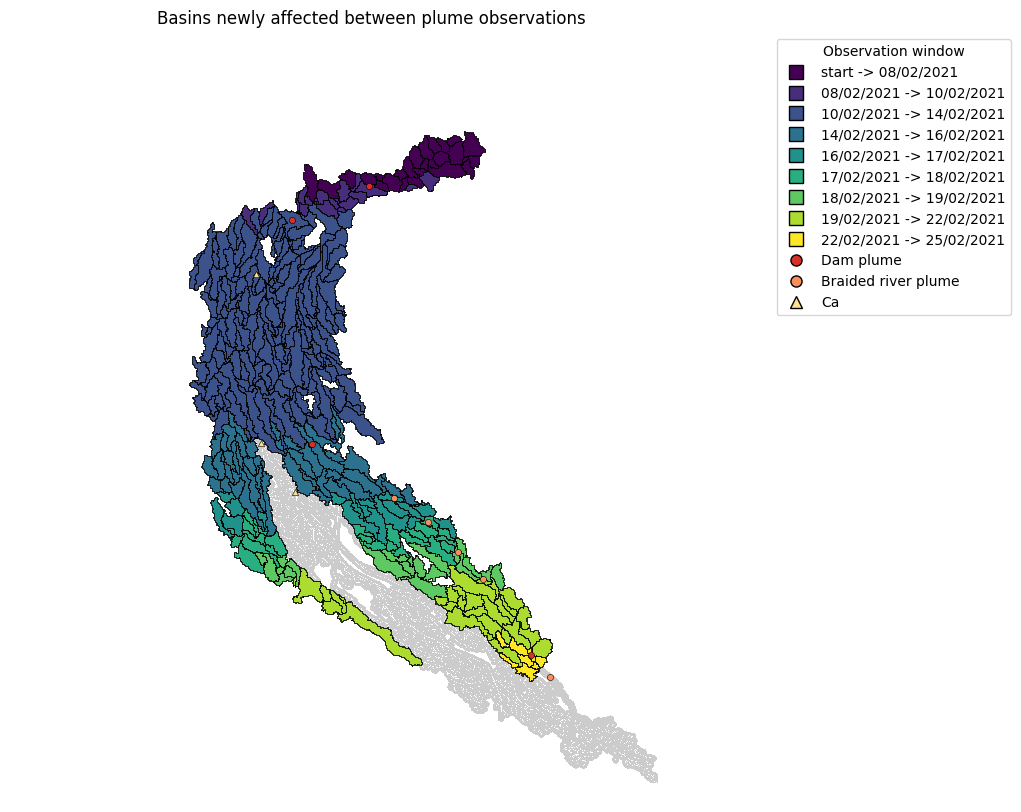

In [ ]:
if river_ranges_df.empty or active_selection_gdf.empty:
    print("No ranges or active selection available for mapping")
else:
    selection_gdf = active_selection_gdf.copy()
    if "basin_id" not in selection_gdf.columns:
        raise ValueError("Active selection GeoDataFrame lacks basin_id column")

    def basin_in_range(basin_id, lower, upper):
        if pd.isna(basin_id):
            return False
        if pd.isna(lower):
            return basin_id <= upper
        return (basin_id >= lower) and (basin_id < upper)

    range_polys = []
    range_defs = []
    for order, row in enumerate(river_ranges_df.itertuples()):
        prev_label = row.previous_event_date if pd.notna(row.previous_event_date) else "start"
        label = f"{prev_label} -> {row.event_date}"
        lower = row.lower_bound_id
        upper = row.upper_bound_id
        range_defs.append({"label": label, "lower": lower, "upper": upper})
        mask = selection_gdf["basin_id"].apply(lambda val: basin_in_range(val, lower, upper))
        subset = selection_gdf[mask].copy()
        if subset.empty:
            continue
        subset["range_label"] = label
        subset["range_order"] = order
        range_polys.append(subset)

    if not range_polys:
        print("No basins matched the derived ranges")
    else:
        range_gdf = gpd.GeoDataFrame(pd.concat(range_polys, ignore_index=True), crs=selection_gdf.crs)
        unique_labels = range_gdf["range_label"].unique()
        cmap = plt.colormaps.get_cmap("viridis").resampled(len(unique_labels))

        fig, ax = plt.subplots(figsize=(10, 10))
        mask_aligned.plot(ax=ax, cmap="Greys", alpha=0.2, add_colorbar=False)

        legend_handles = []
        for i, label in enumerate(unique_labels):
            subset = range_gdf[range_gdf["range_label"] == label]
            color = cmap(i)
            subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.6)
            legend_handles.append(
                Line2D([0], [0], marker="s", linestyle="", markersize=10,
                       markerfacecolor=color, markeredgecolor="black", label=label)
            )

        def assign_range_label(basin_id):
            for rng in range_defs:
                if basin_in_range(basin_id, rng["lower"], rng["upper"]):
                    return rng["label"]
            return None

        plume_points_proj["range_label"] = plume_points_proj["subbasin_id"].apply(assign_range_label)

        point_styles = {
            "dam": {"marker": "o", "color": "#d73027", "label": "Dam plume"},
            "braided river": {"marker": "o", "color": "#fc8d59", "label": "Braided river plume"},
            "canal": {"marker": "^", "color": "#fee090", "label": "Canal plume"},
        }
        point_handles = []
        for loc, style in point_styles.items():
            subset = plume_points_proj[plume_points_proj["location_type"].str.lower() == loc]
            if subset.empty:
                continue
            ax.scatter(
                subset.geometry.x,
                subset.geometry.y,
                s=30,
                c=style["color"],
                marker=style["marker"],
                edgecolors="black",
                linewidths=0.4,
                zorder=5,
            )
            point_handles.append(
                Line2D([0], [0], marker=style["marker"], linestyle="",
                       markerfacecolor=style["color"], markeredgecolor="black",
                       markersize=8, label=style.get("label", loc.title()))
            )

        ax.set_title("Basins newly affected between plume observations")
        ax.set_axis_off()
        ax.legend(handles=legend_handles + point_handles,
                  title="Observation window", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.show()


### Current limitation / debugging note
The final visualization takes basin ranges from plume observations but slices them over the *active* selection (`mask` by default). When a plume’s basin ID lies outside the mask-selected set, `len(subset)` becomes 0 because there are no polygons to color. 

Possible fixes: 1) switch `SELECTION_METHOD` to `"plume_canal"` so the geometry set covers river reaches beyond the command mask, 2) expand the mask selection criteria (e.g., accept partially overlapping basins) so they intersect the plume IDs, or 3) clip the plume ranges against the available `active_selection_ids` before plotting so the code only uses ranges that exist in the current geometry set.

### Next steps
- Join the `coverage` dataframe back to population tables if you need counts per basin.
- Adjust the `coverage_fraction` threshold if you want to focus on basins that are mostly inside the mask but not entirely.
- Export `selected_gdf` as a shapefile or GeoJSON for downstream GIS workflows using `selected_gdf.to_file("selected_basins.geojson", driver="GeoJSON")`.